# Exempelprojekt 3

### Kan vi formulera en modell för att försöka modellera priset på en aktie ?

- Antagligen inte, men kan ändå vara en spännande övning att försöka.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
import os

#Torch importeringar
import torch
import torch.nn as nn

In [2]:
# Läs in historisk data för Amazon-aktien
data = pd.read_csv('AMZN.csv')

In [3]:
data.head(5)

,Date,Open,High,Low,Close,Adj Close,Volume
0,1997-05-15,2.437500,2.500000,1.927083,1.958333,1.958333,72156000
1,1997-05-16,1.968750,1.979167,1.708333,1.729167,1.729167,14700000
2,1997-05-19,1.760417,1.770833,1.625000,1.708333,1.708333,6106800
3,1997-05-20,1.729167,1.750000,1.635417,1.635417,1.635417,5467200
4,1997-05-21,1.635417,1.645833,1.375000,1.427083,1.427083,18853200


In [4]:
data.tail(5)

,Date,Open,High,Low,Close,Adj Close,Volume
5874,2020-09-17,3009.250000,3029.429932,2972.550049,3008.729980,3008.729980,6449100
5875,2020-09-18,3031.739990,3037.800049,2905.540039,2954.909912,2954.909912,8892600
5876,2020-09-21,2906.500000,2962.000000,2871.000000,2960.469971,2960.469971,6117900
5877,2020-09-22,3033.840088,3133.989990,3000.199951,3128.989990,3128.989990,6948800
5878,2020-09-23,3120.429932,3127.000000,2992.379883,2999.860107,2999.860107,5630400


## Visualisera data

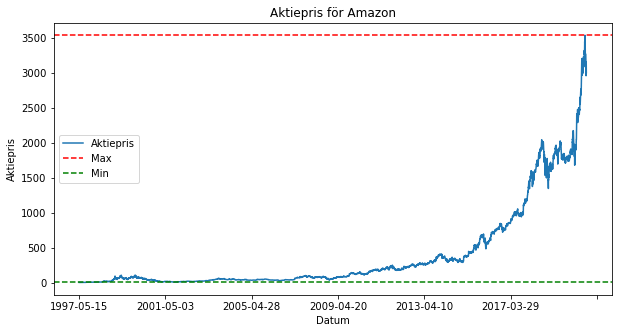

In [5]:
plot = data.plot(x="Date", y="Adj Close", figsize=(10,5))

#Lägg en punkt för min och max
max = data["Adj Close"].max()
min = data["Adj Close"].min()
plot.axhline(y=max, color="r", linestyle="--")
plot.axhline(y=min, color="g", linestyle="--")

plot.set_ylabel("Aktiepris")
plot.set_xlabel("Datum")
plot.set_title(f"Aktiepris för Amazon")
plot.legend(["Aktiepris", "Max", "Min"])
plt.show()

### Kanske ska vi minska vårat intervall något. Låt oss kolla på data från 2015-01-01

In [6]:
#Data från 2015-01-01 till 2020-01-01
data = data[data["Date"] >= "2015-01-01"]

#Index från 0 till antal rader
data = data.reset_index(drop=True)

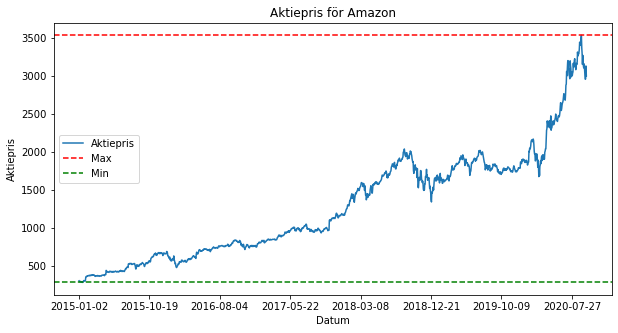

In [7]:
plot = data.plot(x="Date", y="Adj Close", figsize=(10,5))

#Lägg en punkt för min och max
max = data["Adj Close"].max()
min = data["Adj Close"].min()
plot.axhline(y=max, color="r", linestyle="--")
plot.axhline(y=min, color="g", linestyle="--")

plot.set_ylabel("Aktiepris")
plot.set_xlabel("Datum")
plot.set_title(f"Aktiepris för Amazon")
plot.legend(["Aktiepris", "Max", "Min"])
plt.show()

### Förutom att kolla på priset ska vi även kolla på två andra tekniska mått man kan härleda från priset. 

* Glidande medelvärde
* RSI(Relativt styrkeindex)

### Enkelt glidande medelvärde (Simple Moving Average - SMA) 

* Detta innebär att du tar medelvärdet av de senaste n observationerna i tidsserien. Formeln för SMA är:

* SMA = (x₁ + x₂ + x₃ + ... + xₙ) / n där x₁, x₂, ..., xₙ är de n senaste observationerna.

### RSI definition

* RSI står för relativt styrkeindex. Det är ett verktyg inom teknisk analys och analyserar tillgångars moment för att avgöra om de är överköpta eller översålda.

* RSI beräknas med följande ekvation:

* RSI = 100 – 100/(1+medelvärde av stängningar uppåt/medelvärde av stängningar nedåt)

In [8]:
def rsi(data, n):
    "Funktion för att beräkna RSI"
    delta = data["Adj Close"].diff()
    delta = delta[1:]
    up = delta.copy()
    down = delta.copy()
    up[up < 0] = 0
    down[down > 0] = 0
    data['up'] = up
    data['down'] = down
    AVG_Gain = data['up'].rolling(n).mean()
    AVG_Loss = abs(data['down'].rolling(n).mean())
    RS = AVG_Gain / AVG_Loss
    RSI = 100.0 - (100.0 / (1.0 + RS))
    return RSI

In [9]:
#Lägg till glidande medelvärde
data['MA30'] = data["Adj Close"].rolling(30).mean()
data['MA90'] = data["Adj Close"].rolling(90).mean()

#Lägg till RSI
data['RSI14'] = rsi(data, 14)
data['RSI30'] = rsi(data, 30)

data.head(3)


,Date,Open,High,Low,Close,Adj Close,Volume,MA30,MA90,up,down,RSI14,RSI30
0,2015-01-02,312.579987,314.750000,306.959991,308.519989,308.519989,2783200,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-05,307.010010,308.380005,300.850006,302.190002,302.190002,2774200,NaN,NaN,0.0,-6.329987,NaN,NaN
2,2015-01-06,302.239990,303.000000,292.380005,295.290009,295.290009,3519000,NaN,NaN,0.0,-6.899993,NaN,NaN


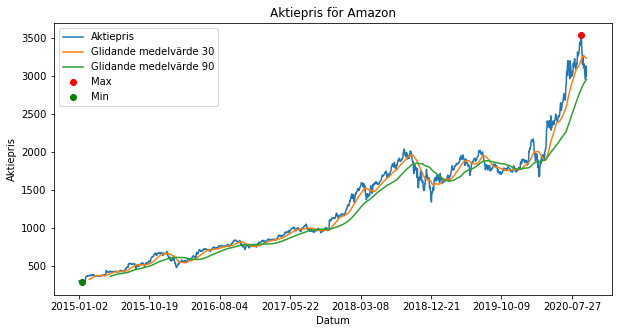

In [10]:
#Glidande medelvärde
plot = data.plot(x="Date", y="Adj Close", figsize=(10,5))

plot.plot(data["Date"], data['MA30'])
plot.plot(data["Date"], data['MA90'])

#Lägg en punkt för min och max
plot.plot(data["Date"].iloc[data["Adj Close"].argmax()], data["Adj Close"].max(), 'ro', markersize=6, label="Max")
plot.plot(data["Date"].iloc[data["Adj Close"].argmin()], data["Adj Close"].min(), 'go', markersize=6, label="Min")

plot.set_ylabel("Aktiepris")
plot.set_xlabel("Datum")
plot.set_title(f"Aktiepris för Amazon")
plot.legend(["Aktiepris", "Glidande medelvärde 30", "Glidande medelvärde 90", "Max", "Min"])
plt.show()


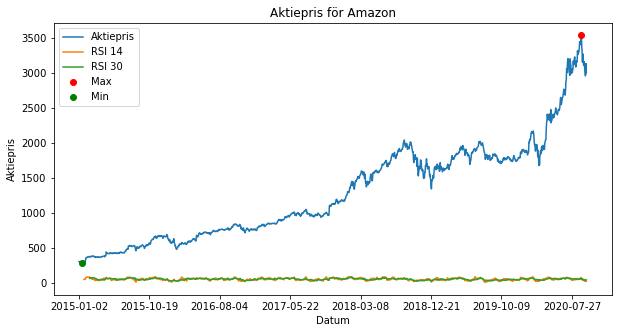

In [11]:
#RSI
plot = data.plot(x="Date", y="Adj Close", figsize=(10,5))
plot.plot(data["Date"], data['RSI14'])
plot.plot(data["Date"], data['RSI30'])

#Lägg en punkt för min och max
plot.plot(data["Date"].iloc[data["Adj Close"].argmax()], data["Adj Close"].max(), 'ro', markersize=6, label="Max")
plot.plot(data["Date"].iloc[data["Adj Close"].argmin()], data["Adj Close"].min(), 'go', markersize=6, label="Min")

plot.set_ylabel("Aktiepris")
plot.set_xlabel("Datum")
plot.set_title(f"Aktiepris för Amazon")
plot.legend(["Aktiepris", "RSI 14", "RSI 30", "Max", "Min"])


### Tidseriedata är svår att prediktera, och den är ofta mycket som är stokastiskt.

Text(0.5, 1.0, 'Dag - dag diff för Amazon')

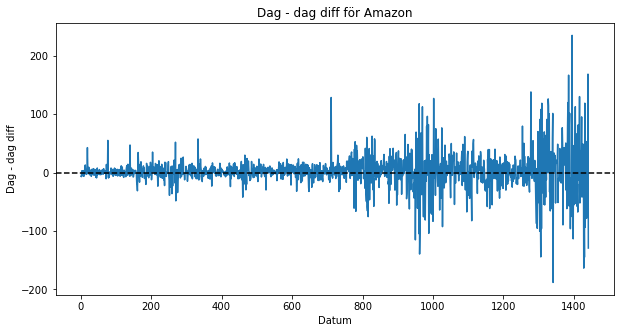

In [12]:
#Visualisera data dag - dag differansen
n=1
data["Adj Close"].diff(n).plot(figsize=(10,5))
plt.axhline(0, color="black", linestyle="--")
plt.ylabel("Dag - dag diff")
plt.xlabel("Datum")
plt.title(f"Dag - dag diff för Amazon")

In [13]:
#Count positive and negative values
positive = data["Adj Close"].diff(n).copy()
positive[positive < 0] = 0
negative = data["Adj Close"].diff(n).copy()
negative[negative > 0] = 0
print(f"Antal positiva dagar: {positive[positive != 0].count()}") #Antal positiva dagar
print(f"Antal negativa dagar: {negative[negative != 0].count()}") #Antal negativa dagar

Antal positiva dagar: 794
Antal negativa dagar: 646


Text(0.5, 1.0, 'Histogram för dag - dag diff för Amazon')

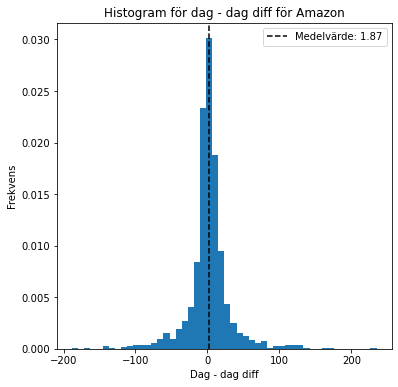

In [14]:
#Ett histogram för dag - dag differansen
data["Adj Close"].diff().hist(figsize=(6,6), bins=50, density=True)
plt.grid(False)
plt.axvline(data["Adj Close"].diff().mean(), color="black", linestyle="--", label=f"Medelvärde: {round(data['Adj Close'].diff().mean(), 2)}")
plt.legend()
plt.ylabel("Frekvens")
plt.xlabel("Dag - dag diff")
plt.title(f"Histogram för dag - dag diff för Amazon")

Text(0.5, 1.0, 'Histogram för dag - dag diff för Amazon')

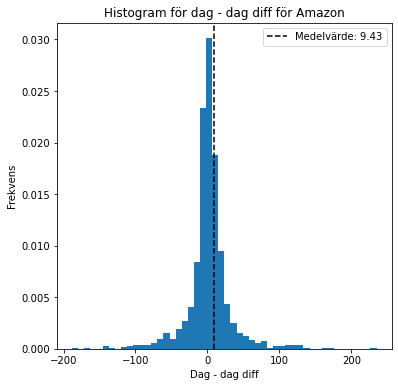

In [15]:
#dag - dag n diff
n = 5
data["Adj Close"].diff().hist(figsize=(6,6), bins=50, density=True)
plt.axvline(data["Adj Close"].diff(n).mean(), color="black", linestyle="--", label=f"Medelvärde: {round(data['Adj Close'].diff(n).mean(), 2)}")
plt.grid(False)
plt.legend()
plt.ylabel("Frekvens")
plt.xlabel("Dag - dag diff")
plt.title(f"Histogram för dag - dag diff för Amazon")

## Hur kan vi formulera ett neuralt nätverk för att försöka modellera priset?

 Ett sätt kan vara att givet **N** historiska dagar prediktera vad priset ska vara efter **P** dagar, eller nästa dag.

 * Dvs. skapa en modell som tar som indata historiska priset och predikterar framtida priset.
 * Vi kan inkorporera mer än bara priset. Som t ex. glidande medelvärde, RSI, eller volym.
 * Kanske skulle ett 1-D CNN kunna vara lämpligt för att hantera tidseriedata. Alternativt ett NN som vi har gått igenom tidigare i kursen.


In [16]:
data.head(3)

,Date,Open,High,Low,Close,Adj Close,Volume,MA30,MA90,up,down,RSI14,RSI30
0,2015-01-02,312.579987,314.750000,306.959991,308.519989,308.519989,2783200,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-05,307.010010,308.380005,300.850006,302.190002,302.190002,2774200,NaN,NaN,0.0,-6.329987,NaN,NaN
2,2015-01-06,302.239990,303.000000,292.380005,295.290009,295.290009,3519000,NaN,NaN,0.0,-6.899993,NaN,NaN


In [17]:
#Ta bort kolumnerna som inte behövs: Date, Open, High, Low, Close, Volume
data = data.drop(columns=["Date", "Open", "High", "Low", "Close", "Volume", "up", "down"])

In [18]:
data.head(3)

,Adj Close,MA30,MA90,RSI14,RSI30
0,308.519989,NaN,NaN,NaN,NaN
1,302.190002,NaN,NaN,NaN,NaN
2,295.290009,NaN,NaN,NaN,NaN


In [19]:
#Ta bort NaN värden
data = data.dropna()

In [20]:
data.head(3)

,Adj Close,MA30,MA90,RSI14,RSI30
89,431.019989,402.040334,368.225444,70.365605,67.664177
90,426.869995,403.866000,369.540444,67.535181,66.968206
91,432.279999,405.933333,370.985889,38.442119,68.798487


## Sätt parametrar för hur många dagar vi ska använda för att förutspå framtiden

In [21]:
N = 20 # Dagar som ska användas för att förutspå
P = 3 # Hur långt fram i tiden vi vill förutspå - 1 dags förutspåelse

In [22]:
#Lägg till kolumnen som ska förutspås. Shifta Adj Close med P dagar
data[f"Adj Close +{P}"] = data["Adj Close"].shift(-P)

In [23]:
data.head(3)

,Adj Close,MA30,MA90,RSI14,RSI30,Adj Close +3
89,431.019989,402.040334,368.225444,70.365605,67.664177,426.000000
90,426.869995,403.866000,369.540444,67.535181,66.968206,425.239990
91,432.279999,405.933333,370.985889,38.442119,68.798487,421.709991


In [24]:
print(len(data))

1353


## Skapa träningsdata

* Vi skapar en funktion för att skapa träningsdata (**X**, *y*).
* Vi gör detta genom att appenda **N** historiska observationer av Adj price, MA30, MA90, RSI14 och RSI30 till **X**.


In [25]:
#Skapa en funktion som skapar träningsdatan. 
# Dvs. där ett träningsexempel är en matris med N*3 rader pga. (Adj Close, MA30, MA90), och där målet är att förutspå (Adj Close - Adj Close + P)

def create_train_data(data, N, P):
    """
    Funktion för att skapa träningsdata.
    data: DataFrame
    N: Antal dagar som ska användas för att förutspå
    P: Hur långt fram i tiden vi vill förutspå
    """

    X_train = []
    y_train = []

    for i in range(len(data) - N):
        x = data.iloc[i:i+N].values
        y = data.iloc[i+N-1][f"Adj Close +{P}"]

        #Check so that the data is not NaN
        if np.isnan(x).any() or np.isnan(y).any():
            continue
        
        X_train.append(x)
        y_train.append(y)
    
    #Ta bort den sista kolumnen i X_train(där finns Adj Close + P)
    X = np.array(X_train)[..., :-1]

    y = np.expand_dims(np.array(y_train), axis=-1)

    return X, y

In [26]:
data_x, data_y = create_train_data(data, N, P)

In [27]:
data_x.shape, data_y.shape

((1331, 20, 5), (1331, 1))

## Viktigt att normalisera datan för att få en skapligt vettig träning. Vi gör detta via min-max.

In [28]:
#Normalisera datan. För varje kolumn, normalisera till 0-1
def normalize_data(data, mins=None, maxs=None):
    "Normalisera datan"
    if mins is None or maxs is None:
        mins = np.min(data, axis=(0, 1))
        maxs = np.max(data, axis=(0, 1))
    return (data - mins) / (maxs - mins), mins, maxs

#Normalisera datan. Spara även min och max värdena för att kunna återställa datan. Senare
data_x, mins, maxs = normalize_data(data_x)
#data_y, y_mins, y_maxs = normalize_data(data_y)

In [29]:
#byt plats på axlarna 1 och 2 För träning av vårat nätverk senare. Nätverk förväntar sig (batch, kanaler, vektor)
data_x = np.swapaxes(data_x, 1, 2)

In [30]:
data_x.shape, data_y.shape

((1331, 5, 20), (1331, 1))

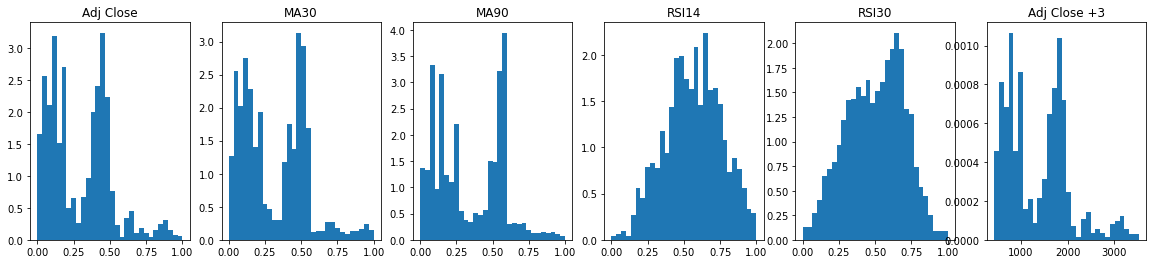

In [31]:
#Histogram över data i subplots för att se att datan är normaliserad. histogram
fig, axs = plt.subplots(1, 6, figsize=(20,4))
kolumner = ["Adj Close", "MA30", "MA90", "RSI14", "RSI30", f"Adj Close +{P}"]
for i in range(6):
    if i<5:
        axs[i].hist(data_x[:, i, :].flatten(), bins=30, density=True)
    else:
        axs[i].hist(data_y.flatten(), bins=30, density=True)
    axs[i].grid(False)
    axs[i].set_title(kolumner[i])

## Splitta träning och validering och skapa en DataLoader

* Vi splittar datan med **80%** träning och **20%** för validering. I detta fallet är det viktigt att vi väljer distinkta tidsintervall. Dvs. inte shufflar datan, då det då kommer att finnas starkt överlapp mellan träning och validering.

In [32]:
training_interval = 0.8 # 80% av datan ska användas för träning

training_data = (data_x[:int(len(data)*training_interval)], data_y[:int(len(data)*training_interval)])
validation_data = (data_x[int(len(data)*training_interval):], data_y[int(len(data)*training_interval):])


In [33]:
training_data[0].shape, validation_data[0].shape

((1082, 5, 20), (249, 5, 20))

In [34]:
class datal(torch.utils.data.Dataset):
    def __init__(self, data):
        self.xdata = data[0]
        self.ydata = data[1]
        
    def __getitem__(self, idx):
        return (self.xdata[idx], self.ydata[idx])
    
    def __len__(self):
        return self.xdata.shape[0]

training_data_l = datal(training_data)

#Skapa en dataloader för att kunna iterera över datan
training_loader = torch.utils.data.DataLoader(training_data_l, batch_size=32, shuffle=True)

Text(0.5, 1.0, 'Aktiepris för Amazon')

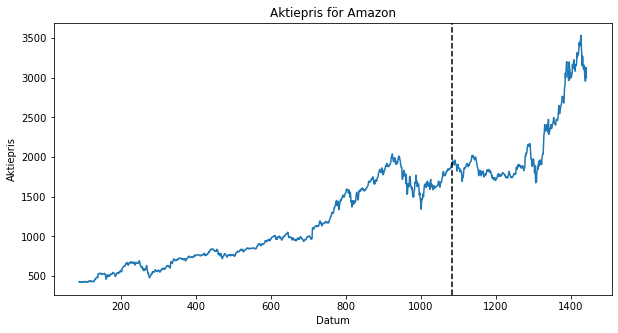

In [35]:
#visualisera träning och test data i grafen vart i tiden
plt.figure(figsize=(10,5))
plt.plot(data["Adj Close"])
plt.axvline(len(data)*training_interval, color="black", linestyle="--")
plt.ylabel("Aktiepris")
plt.xlabel("Datum")
plt.title(f"Aktiepris för Amazon")

### Definera en PyTorch modell. 

* Ett 1D-CNN med input *(N, N_f)*, där *N* är vår tidsserielängd och *N_f* antalet features dvs. 5st (Adj Close price, MA30, MA90, RSI14, RSI30)
* Vi använder kernel_size 3
* Kanaler = 16, dvs. antalet filter

In [36]:
#Skapa en modell i PyTorch. En 1D konvolutionell modell. Definerad sekvensiellt

kanaler = 16
N_f = 5

model = nn.Sequential(
    # Första 1D konvolutionella lagret
    nn.Conv1d(in_channels=N_f, out_channels=kanaler, kernel_size=3, padding=1), # 1D konvolutionellt lager. 3x3 kärna, padding=1
    nn.ReLU(),  # Aktiveringsfunktionen ReLU

    # Andra 1D konvolutionella lagret
    nn.Conv1d(in_channels=kanaler, out_channels=kanaler*2, kernel_size=3, padding=1), # 1D konvolutionellt lager. 3x3 kärna, padding=1
    nn.ReLU(),  # Aktiveringsfunktionen ReLU

    # Tredje 1D konvolutionella lagret
    nn.Conv1d(in_channels=kanaler*2, out_channels=kanaler*4, kernel_size=3, padding=1), # 1D konvolutionellt lager. 3x3 kärna, padding=1
    nn.ReLU(),  # Aktiveringsfunktionen ReLU

    # Flatten (gör om datan till en vektor)
    nn.Flatten(),

    # Första fullt kopplade lagret
    nn.Linear(kanaler*4 * N, 32),  # Fullt kopplat lager.  32 output noder
    nn.ReLU(),  # Aktiveringsfunktionen ReLU

    # Andra fullt kopplade lagret
    nn.Linear(32, 1)  # Fullt kopplat lager. 32 input noder, 1 output nod
)

In [37]:
#Printa hur många parametrar modellen har
print(f"Modellen har {sum(p.numel() for p in model.parameters())} parametrar")

Modellen har 49057 parametrar


### Träna modellen

In [38]:
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

In [39]:
#Träningsloopen
epochs = 100
losses = []
for i in range(epochs):

    for x, ytarget in training_loader:
        
        #Konvertera till float
        x = x.float()

        #Beräkna felet
        loss = torch.mean((model(x) - ytarget)**2)

        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())

    if i % 10 == 0:
        print(f"Epoch: {i}, Loss: {loss.item()}")

Epoch: 0, Loss: 1497542.4662273286
Epoch: 10, Loss: 9093.060079228402
Epoch: 20, Loss: 5929.724733627009
Epoch: 30, Loss: 3008.437311185898
Epoch: 40, Loss: 7910.428387916134
Epoch: 50, Loss: 3865.0911232801864
Epoch: 60, Loss: 3629.772061659855
Epoch: 70, Loss: 1424.9520719925256
Epoch: 80, Loss: 1154.4580913220489
Epoch: 90, Loss: 1052.9030546308356


### Prediktion på Träningsdata

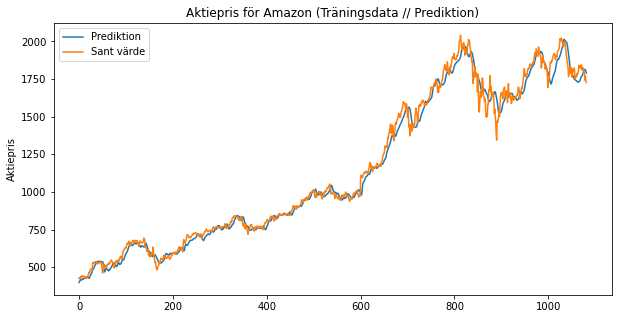

In [40]:
#Prediktera på all Träningsdata
preds_t = model(torch.tensor(training_data[0]).float())

#Återställ datan till normalt värde genom att multiplicera med max-min och addera min
preds_t = preds_t.detach().numpy()[:,0] #* (y_maxs - y_mins) + y_mins
y = training_data[1] #* (y_maxs - y_mins) + y_mins

#Visualisera prediktionerna
plt.figure(figsize=(10,5))
plt.plot(preds_t, label="Prediktion")
plt.plot(y, label="Sant värde")
plt.ylabel("Aktiepris")
plt.title(f"Aktiepris för Amazon (Träningsdata // Prediktion)")
plt.legend()
plt.show()

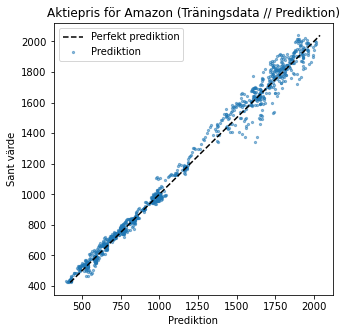

In [41]:
plt.figure(figsize=(5,5))
plt.scatter(preds_t, y, label="Prediktion", alpha=0.5, s=5)
#Linje för perfekt prediktion
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="black", linestyle="--", label="Perfekt prediktion")
plt.ylabel("Sant värde")
plt.xlabel("Prediktion")
plt.title(f"Aktiepris för Amazon (Träningsdata // Prediktion)")
plt.legend()

### Prediktion på Valideringsdata

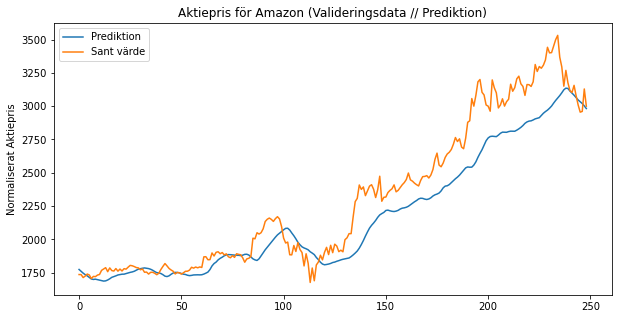

In [42]:
#Prediktera på all Valideringsdata
preds = model(torch.tensor(validation_data[0]).float())

#Återställ datan till normalt värde genom att multiplicera med max-min och addera min
preds = preds.detach().numpy()[:,0] #* (y_maxs - y_mins) + y_mins
val_y = validation_data[1] #*(y_maxs - y_mins) + y_mins

#Visualisera prediktionerna
plt.figure(figsize=(10,5))
plt.plot(preds, label="Prediktion")
plt.plot(val_y, label="Sant värde")
plt.ylabel("Normaliserat Aktiepris")
plt.title(f"Aktiepris för Amazon (Valideringsdata // Prediktion)")
plt.legend()
plt.show()

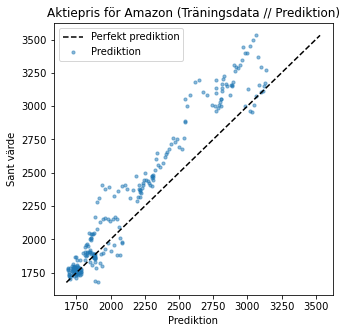

In [43]:
plt.figure(figsize=(5,5))
plt.scatter(preds, val_y, label="Prediktion", alpha=0.5, s=10)
#Linje för perfekt prediktion
plt.plot([val_y.min(), val_y.max()], [val_y.min(), val_y.max()], color="black", linestyle="--", label="Perfekt prediktion")
plt.ylabel("Sant värde")
plt.xlabel("Prediktion")
plt.title(f"Aktiepris för Amazon (Träningsdata // Prediktion)")
plt.legend()

### Kanske tänker man nu wow vilken bra modell! Men man måste tänka till lite här. Är det faktiskt korrekt att göra såhär?

* Svaret är nej.
* Även om observationerna i sig inte är sedda under träningen, så använder vi ju features som är baserade på det sanna värdet.
* Detta skulle inte funka i verkligheten, då vi inte har detta tillgängligt.

### Så vad kan vi göra?

* Vi kan prediktera ett steg, och använda det steget för att beräkna om våra features.
* På detta sättet "fuskar" vi inte, utan vi använder bara modellens prediktioner på priset.
* Vi kan göra detta genom att iterera över datan och prediktera ett steg framåt, och uppdatera våra features.

In [44]:
def skapa_prediktionsdata(xt_df, N, P, mins, maxs):
    """Funktion för att skapa prediktionsdata.
    xt_df: DataFrame
    N: Antal dagar som ska användas för att förutspå
    P: Hur långt fram i tiden vi vill förutspå
    mins: Min värden för normalisering
    maxs: Max värden för normalisering
    """
    xt = xt_df.copy()

    #Beräkna MA30 och MA90
    xt['MA30'] = xt["Adj Close"].rolling(30).mean()
    xt['MA90'] = xt["Adj Close"].rolling(90).mean()

    #Beräkna RSI14 och RSI30
    xt['RSI14'] = rsi(xt, 14)
    xt['RSI30'] = rsi(xt, 30)

    #Lägg till kolumnen som ska förutspås. Shifta Adj Close med P dagar
    xt[f"Adj Close +{P}"] = xt["Adj Close"].shift(-P)

    #Ta bort NaN värden
    xt = xt.dropna()

    #Ta bort kolumnerna up och down
    xt = xt.drop(columns=["up", "down"])

    #Skapa observationer
    X, _ = create_train_data(xt, N, P)

    #Normalisera datan. med samma min och max värden som definerades för träningsdatan ovan
    X, _, _ = normalize_data(X, mins, maxs)
    
    #byt plats på axlarna 1 och 2
    X = np.swapaxes(X, 1, 2)

    return X


In [45]:
# Korrekt sätt att göra det på. Dvs prediktera på en dag i taget och använda prediktionen för nästa dag. 
# Dvs appenda prediktionen till x och ta bort den sisya raden i x.
# Problem att vi också måste beräkna uppdatera MA30 och MA90, RSI14 och RSI30.

tlen = len(training_data[0])
xt_df = pd.DataFrame(data["Adj Close"].values[:tlen]) #Skapa en dataframe med träningsdatan
xt_df_gt = pd.DataFrame(data["Adj Close"].values) #Skapa en dataframe med all data

#Namnge kolumnen
xt_df.columns = ["Adj Close"]

#Skapa en lista för prediktionerna
preds = []

#Hur långt fram i tiden vi vill förutspå
Forecast = 400 

for i in range(Forecast):

    #Använd xt för att skapa prediktionsexempel(-200 har ingen betydelse här)
    prediktionsdata = skapa_prediktionsdata(xt_df[-200:], N, P, mins, maxs)

    #Prediktera på sista tränings exemplet
    pred = model(torch.tensor(prediktionsdata[-1:]).float()).float().detach().numpy()[0][0]

    #Normalisera tillbaka prediktionen
    pred = pred #* (y_maxs - y_mins) + y_mins

    #Lägg till prediktionen i xt_df
    xt_df = xt_df.append({"Adj Close": pred}, ignore_index=True) 
    
    if i % 30 == 0:
        print(f"Prediktion {i}: {pred}")


Prediktion 0: 1741.856689453125
Prediktion 30: 1410.73779296875
Prediktion 60: 1017.951904296875
Prediktion 90: 730.7280883789062
Prediktion 120: 534.2792358398438
Prediktion 150: 407.4384765625
Prediktion 180: 324.8081970214844
Prediktion 210: 272.0291748046875
Prediktion 240: 243.2998809814453
Prediktion 270: 226.3623504638672
Prediktion 300: 217.30767822265625
Prediktion 330: 212.33978271484375
Prediktion 360: 209.58163452148438
Prediktion 390: 208.0662078857422


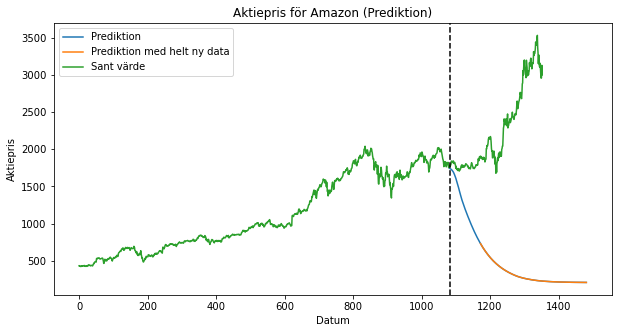

In [46]:
#Konvertera dataframes till numpy arrays
if isinstance(xt_df, pd.DataFrame): xt_df = xt_df.values
if isinstance(xt_df_gt, pd.DataFrame): xt_df_gt = xt_df_gt.values

plt.figure(figsize=(10,5))
plt.plot(np.arange(tlen, tlen+Forecast), xt_df[tlen:], label = "Prediktion")
plt.plot(np.arange(tlen+90, len(xt_df)), xt_df[tlen+90:], label = "Prediktion med helt ny data")
plt.plot(xt_df_gt, label="Sant värde")
plt.axvline(tlen, color="black", linestyle="--")
plt.ylabel("Aktiepris")
plt.xlabel("Datum")
plt.title(f"Aktiepris för Amazon (Prediktion)")
plt.legend()
plt.show()


### Avslutande kommentarer
* Detta är en väldigt enkel modell. Det finns många sätt att förbättra den. För den intresserade finns mer anvancerade modeller som *LSTM* och *GRU*.

* Det går även att förbättra modellen ovan genom hyperoptimerisering av antalet lager och antalet noder i varje lager etc.

* Det finns många sätt att förbättra datan. T.ex. genom att använda mer data, eller extrahera fler features än de vi använde ovan.

* Om prisdatan skulle röra sig utanför vad vi har tränat skulle det vara extra svårt. Då hade vi fått tänka på något annat sätt att normalisera på, eller prediktera på. Kanske differansen dag-dag hade varit bättre då.

Men det är också ett svårt problem...

